# Libraries


In [104]:
import pandas as pd
import matplotlib.pyplot as plt

# Variables

**Duty cycle**

In [105]:
#10797420 so 20 % 50 TODO check this
timeSleepSeconds = (20 % 50 + 5) / 10.0 
timeSleepMicroseconds = timeSleepSeconds * 1000000
print(timeSleepMicroseconds, "microseconds")

2500000.0 microseconds


**Battery**

In [106]:
#10797420 so 7420 TODO check this
JBattery= 7420%5000+15000
print(JBattery, "Joule")

17420 Joule


# Dataset Analysis

**Structure of the dataset**

In [107]:
df_sleep = pd.read_csv('data/deep_sleep.csv')
df_sender = pd.read_csv('data/sender.csv')
df_sensor = pd.read_csv('data/sensor-read.csv')

**Description of the dataset**

In [108]:
print(df_sleep.describe())
print(df_sender.describe())
print(df_sensor.describe())

              Data
count  1531.000000
mean    178.962064
std     197.935398
min      45.050000
25%      45.640000
50%      45.790000
75%     253.500000
max     636.760000
              Data
count  1394.000000
mean    607.412654
std       8.878444
min     599.530000
25%     605.380000
50%     605.960000
75%     606.580000
max     687.930000
              Data
count  1033.000000
mean    294.470242
std      56.413627
min     235.430000
25%     237.090000
50%     311.000000
75%     351.070000
max     352.220000


# Average cycle power consumption



Computing the average power consuption during each functional state requires filtering the datapoints according to empirical observation of the plotted data.

| deep sleep | idle              | WiFi on  |
|------------|-------------------|----------|
| < 100 mW   | >200 mW, < 300 mW | > 400 mW | 

<Axes: title={'center': 'Power consumption (Deep Sleep)'}, xlabel='time [s]', ylabel='Power [mW]'>

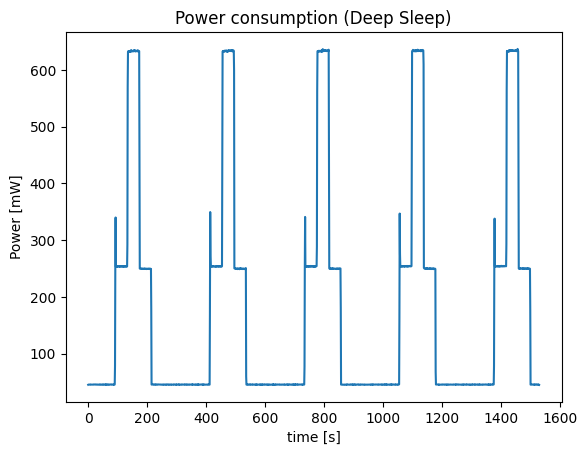

In [109]:
df_sleep.plot(
    xlabel="time [s]",
    ylabel="Power [mW]",
    title="Power consumption (Deep Sleep)",
    kind="line",
    legend=False,
)

In [110]:
deep_sleep_mean = round(df_sleep['Data'][df_sleep['Data'] < 100].mean(), 3)
idle_mean = round(df_sleep['Data'][df_sleep['Data'] > 200][df_sleep['Data'] < 300].mean(), 3)
tx_mean = round(df_sleep['Data'][df_sleep['Data'] > 400].mean(), 3)

print ("Deep Sleep Mean:", deep_sleep_mean, "mW")
print ("Idle Mean:", idle_mean, "mW")
print ("WiFi on Mean:", tx_mean, "mW")


Deep Sleep Mean: 45.777 mW
Idle Mean: 252.222 mW
WiFi on Mean: 627.259 mW


# Data trasmissions consumption avgs


trasmission data from sender.csv, analysis on power consumption at 2dBm, 19.5dBm and idle

<Axes: title={'center': 'Power consumption (Sender)'}, xlabel='time [s]', ylabel='Power [mW]'>

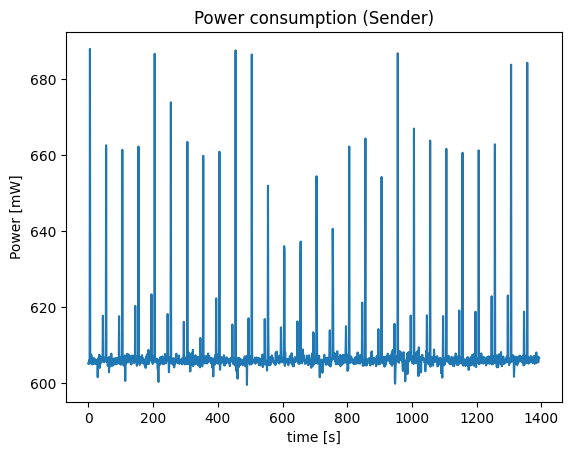

In [111]:
df_sender.plot(
    xlabel="time [s]",
    ylabel="Power [mW]",
    title="Power consumption (Sender)",
    kind="line",
    legend=False,
)

In [112]:
idle_wifi = round(df_sender['Data'][df_sender['Data'] < 610].mean(), 3)
tx2db_wifi = round(df_sender['Data'][df_sender['Data'] > 610][df_sender['Data'] < 630].mean(), 3)
tx19db_wifi = round(df_sender['Data'][df_sender['Data'] > 640].mean(), 3)
print ("Idle Mean:", idle_wifi, "mW")
print ("Tx 2dBm Mean:", tx2db_wifi, "mW")
print ("Tx 19.5dBm Mean:", tx19db_wifi, "mW")

Idle Mean: 605.889 mW
Tx 2dBm Mean: 617.883 mW
Tx 19.5dBm Mean: 667.411 mW


# Sensor reading power consumption avg

<Axes: title={'center': 'Power consumption (Sensor)'}, xlabel='time [s]', ylabel='Power [mW]'>

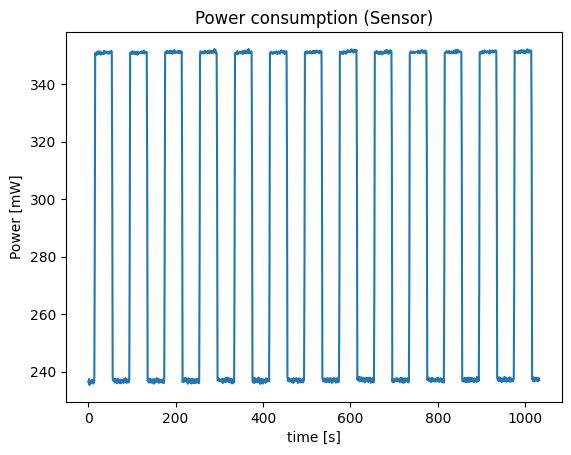

In [113]:
df_sensor.plot(
    xlabel="time [s]",
    ylabel="Power [mW]",
    title="Power consumption (Sensor)",
    kind="line",
    legend=False,
)

In [114]:
sensor_off_mean = round(df_sensor['Data'][df_sensor['Data'] < 300].mean(), 3)
sensor_on_mean = round(df_sensor['Data'][df_sensor['Data'] > 300].mean(), 3)
print ("Sensor off Mean:", sensor_off_mean, "mW")
print ("Sensor on Mean:", sensor_on_mean, "mW")

Sensor off Mean: 238.019 mW
Sensor on Mean: 350.162 mW


# Energy computation


In [115]:
states = [
    "Deep Sleep",
    "Idle",
    "Tx",
    "Sensor On",
    "Sensor Off",
    "WiFi idle",
    "WiFi Tx 2dBm",
    "WiFi Tx 19.5dBm",
]

power_avgs = [
    deep_sleep_mean,
    idle_mean,
    tx_mean,
    sensor_on_mean,
    sensor_off_mean,
    idle_wifi,
    tx2db_wifi,
    tx19db_wifi,
]

sorted_power_data = zip(states, power_avgs)
# print(sorted_power_data)
print("\nAverage Power Consumption for each state:")
for state, power in sorted_power_data:
    print(f"{state}: {power} mW")


Average Power Consumption for each state:
Deep Sleep: 45.777 mW
Idle: 252.222 mW
Tx: 627.259 mW
Sensor On: 350.162 mW
Sensor Off: 238.019 mW
WiFi idle: 605.889 mW
WiFi Tx 2dBm: 617.883 mW
WiFi Tx 19.5dBm: 667.411 mW


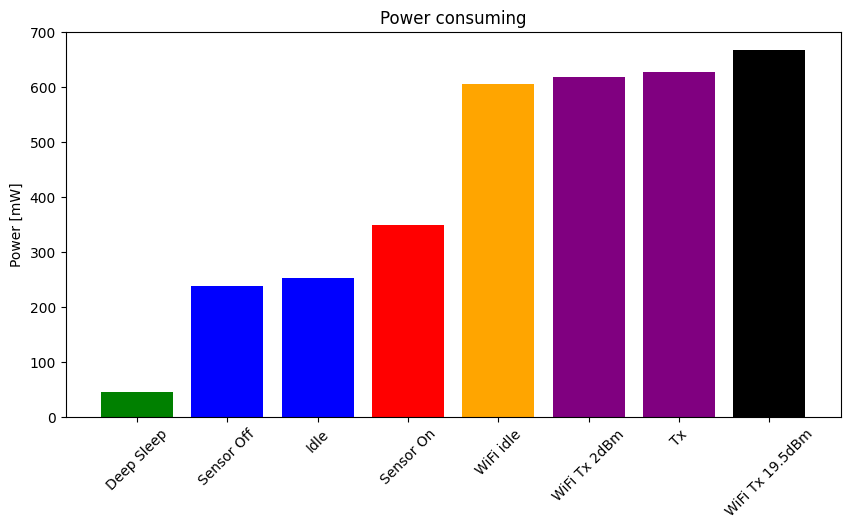

In [116]:
sorted_power_data = sorted(zip(power_avgs, states))
sorted_power_values, sorted_states = zip(*sorted_power_data)

plt.figure(figsize=(10, 5))
plt.bar(
    sorted_states,
    sorted_power_values,
    color=["green", "blue", "blue", "red", "orange", "purple", "purple", "black"],
)

plt.ylabel("Power [mW]")
plt.title("Power consuming")
plt.xticks(rotation=45)

plt.show()

In our case we don't consume Transmission power at 19.5 dBm, due the fact that we use the component only at 2dBm

# Time Estimation of our simulation

Dataset shape (working cycle of the esp): 
    Timestamp                   Status
0          0                  Booting
1        951          Setup completed
2       1769  Sensor reading complete
3     193049         Wifi initialized
4     193213             Message sent
5     247837          WiFi turned off
6     248095      Entering deep sleep
     Timestamp                   Status  Duration
1          951          Setup completed     951.0
2         1769  Sensor reading complete     818.0
3       193049         Wifi initialized  191280.0
4       193213             Message sent     164.0
5       247837          WiFi turned off   54624.0
..         ...                      ...       ...
184       1830  Sensor reading complete     873.0
185     188583         Wifi initialized  186753.0
186     188734             Message sent     151.0
187     243303          WiFi turned off   54569.0
188     243561      Entering deep sleep     258.0

[188 rows x 3 columns]


Average time for each oper

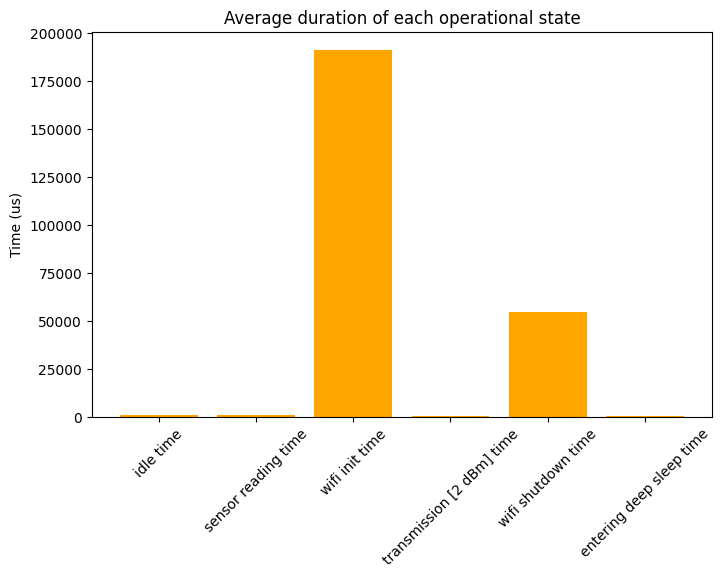

In [117]:
time_dataset = pd.read_csv("data/timings_from_simulation.csv")
print("Dataset shape (working cycle of the esp): \n", time_dataset.head(7))

time_dataset["Duration"] = time_dataset["Timestamp"].diff()
time_dataset.dropna(inplace=True)


print(time_dataset)
diff_labels = [
    "idle time",
    "sensor reading time",
    "wifi init time",
    "transmission [2 dBm] time",
    "wifi shutdown time",
    "entering deep sleep time"
]

time_results = dict(zip(diff_labels, time_dataset["Duration"].values[:len(diff_labels)]))

print("\n\nAverage time for each operational state: \n")
for key, value in time_results.items():
    print(f"{key}: {value:.2f} us")

plt.figure(figsize=(8, 5))
plt.bar(time_results.keys(), time_results.values(), color='orange') # type: ignore
plt.ylabel("Time (us)")
plt.title("Average duration of each operational state")
plt.xticks(rotation=45)
plt.show()


# Energy consumption for each state

In [118]:
energy_idle = (idle_mean * time_results["idle time"]) / 1000000000 
energy_sensor_reading = (sensor_on_mean * time_results["sensor reading time"]) / 1000000000
energy_wifi_init = (idle_wifi * time_results["wifi init time"]) / 1000000000
energy_wifi_tx = (tx2db_wifi * time_results["transmission [2 dBm] time"]) / 1000000000
energy_wifi_shutdown = (idle_wifi * time_results["wifi shutdown time"]) / 1000000000
# timeSleepMicroseconds is the time spent in deep sleep
energy_deep_sleep = (deep_sleep_mean * timeSleepMicroseconds) / 1000000000 

print("\n\nEnergy consumption for each state: \n")
print(f"Idle: {energy_idle:.6f} J")
print(f"Sensor Reading: {energy_sensor_reading:.6f} J")
print(f"WiFi Init: {energy_wifi_init:.6f} J")
print(f"WiFi Tx: {energy_wifi_tx:.6f} J")
print(f"WiFi Shutdown: {energy_wifi_shutdown:.6f} J")
print(f"Deep Sleep: {energy_deep_sleep:.6f} J")

totEnergy = energy_idle + energy_sensor_reading + energy_wifi_init + energy_wifi_tx + energy_wifi_shutdown + energy_deep_sleep
totTimeMicroseconds = time_results["idle time"] + time_results["sensor reading time"] + time_results["wifi init time"] + time_results["transmission [2 dBm] time"] + time_results["wifi shutdown time"] + timeSleepMicroseconds
totTime = totTimeMicroseconds / 1000000



Energy consumption for each state: 

Idle: 0.000240 J
Sensor Reading: 0.000286 J
WiFi Init: 0.115894 J
WiFi Tx: 0.000101 J
WiFi Shutdown: 0.033096 J
Deep Sleep: 0.114443 J


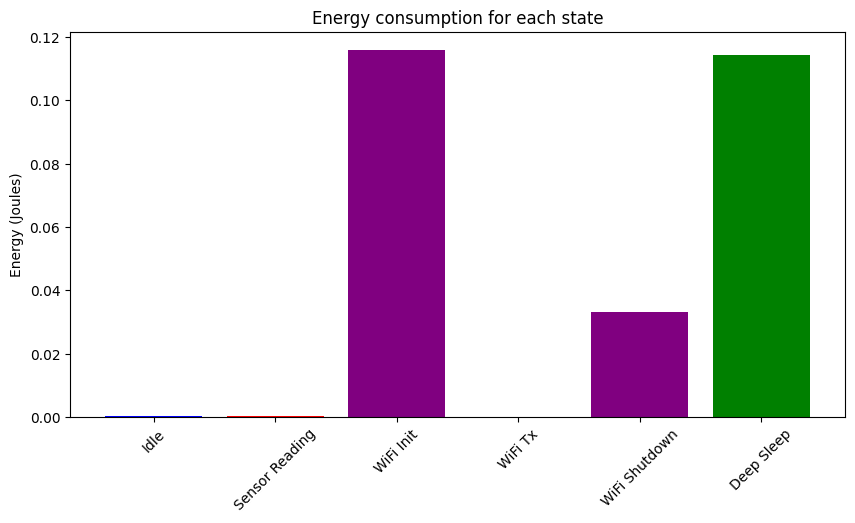

In [119]:
# plotting energy consumption
energy_states = [
    "Idle",
    "Sensor Reading",
    "WiFi Init",
    "WiFi Tx",
    "WiFi Shutdown",
    "Deep Sleep",
]

energy_values = [
    energy_idle,
    energy_sensor_reading,
    energy_wifi_init,
    energy_wifi_tx,
    energy_wifi_shutdown,
    energy_deep_sleep,
]

plt.figure(figsize=(10, 5))
plt.bar(
    energy_states,
    energy_values,
    color=["blue", "red", "purple", "black", "purple", "green"],
)
plt.ylabel("Energy (Joules)")
plt.title("Energy consumption for each state")
plt.xticks(rotation=45)
plt.show()

# Battery life computation

In [120]:
duty_cycles = JBattery/totEnergy
print(f"duty cycles: {duty_cycles:.0f}")

battery_life = duty_cycles*totTime/3600
print(f"battery life: {battery_life:.2f} h")

duty cycles: 65970
battery life: 50.35 h
